<a href="https://colab.research.google.com/github/rackxy/Business_analytics/blob/main/gen%20ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

In [22]:
# Load MNIST (60,000 train + 10,000 test images of digits 0-9)
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

# Keep only digits 0 and 1
def filter_01(x, y):
    mask = (y == 0) | (y == 1)
    return x[mask], y[mask]

x_train, y_train = filter_01(x_train_full, y_train_full)
x_test, y_test = filter_01(x_test_full, y_test_full)

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(f"Training images: {x_train.shape}, Training labels: {y_train.shape}")
print(f"Test images: {x_test.shape}, Test labels: {y_test.shape}")
print(f"Class balance (train): 0s = {(y_train==0).sum()}, 1s = {(y_train==1).sum()}")

Training images: (12665, 28, 28), Training labels: (12665,)
Test images: (2115, 28, 28), Test labels: (2115,)
Class balance (train): 0s = 5923, 1s = 6742


In [23]:
# Flattened versions for the discriminative model (logistic regression needs 1D input per sample)
x_train_flat = x_train.reshape(len(x_train), -1)   # shape: (N, 784)
x_test_flat = x_test.reshape(len(x_test), -1)

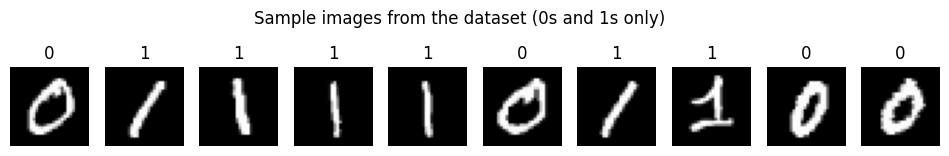

In [24]:
# Quick look at some sample digits
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(str(y_train[i]))
    ax.axis("off")
plt.suptitle("Sample images from the dataset (0s and 1s only)")
plt.show()

In [9]:
clf = LogisticRegression(max_iter=1000)
clf.fit(x_train_flat, y_train)

y_pred = clf.predict(x_test_flat)
acc = accuracy_score(y_test, y_pred)

print(f"Discriminative model (Logistic Regression) accuracy: {acc*100:.2f}%")
print()
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["digit 0", "digit 1"]))

Discriminative model (Logistic Regression) accuracy: 99.95%

Classification report:
              precision    recall  f1-score   support

     digit 0       1.00      1.00      1.00       980
     digit 1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



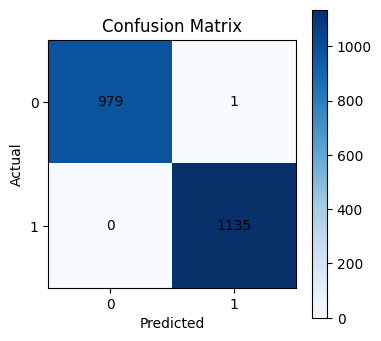

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.colorbar()
plt.show()

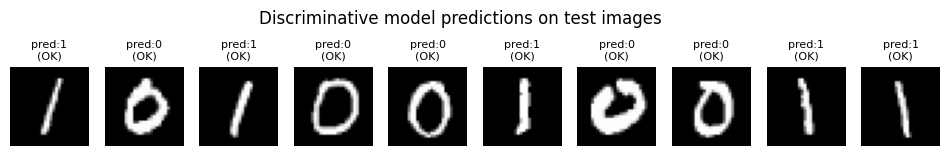

In [11]:
# Visualize a few predictions: real image vs predicted label
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_test[i], cmap="gray")
    correct = "OK" if y_pred[i] == y_test[i] else "WRONG"
    ax.set_title(f"pred:{y_pred[i]}\n({correct})", fontsize=8)
    ax.axis("off")
plt.suptitle("Discriminative model predictions on test images")
plt.show()

In [12]:
latent_dim = 2  # small on purpose, so we can easily sample and visualize the latent space

# --- Encoder ---
encoder_input = keras.Input(shape=(28, 28))
x = layers.Flatten()(encoder_input)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="linear", name="latent")(x)
encoder = keras.Model(encoder_input, latent, name="encoder")

# --- Decoder ---
decoder_input = keras.Input(shape=(latent_dim,))
x = layers.Dense(32, activation="relu")(decoder_input)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
decoder_output = layers.Reshape((28, 28))(x)
decoder = keras.Model(decoder_input, decoder_output, name="decoder")

# --- Full Autoencoder ---
autoencoder_input = keras.Input(shape=(28, 28))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)
autoencoder = keras.Model(autoencoder_input, decoded, name="autoencoder")

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │       104,674 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28)         │       105,456 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,130 (820.82 KB)

 Trainable params: 210,130 (820.82 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = autoencoder.fit(
    x_train, x_train,          # input = target: the model learns to reconstruct its input
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1,
)

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.2697 - val_loss: 0.1719
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1630 - val_loss: 0.1499
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1454 - val_loss: 0.1418
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1410 - val_loss: 0.1396
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1387 - val_loss: 0.1378
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1372 - val_loss: 0.1369
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1360 - val_loss: 0.1358
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1351 - val_loss: 0.1342
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1343 - val_loss: 0.1335
Epoch 10/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1335 - val_loss: 0.1330
Epoch 11/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1328 - val_loss: 0.1321
Epoch 12/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1

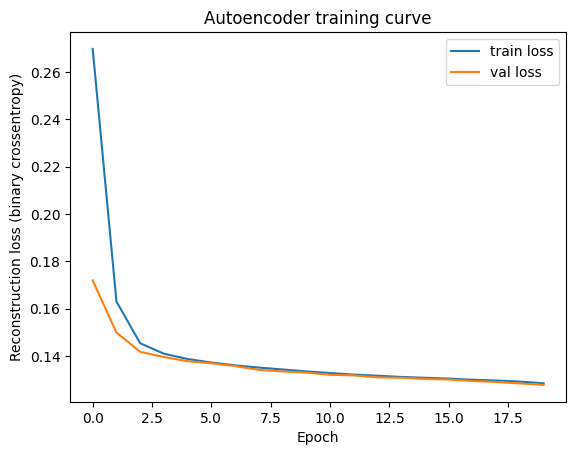

In [14]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss (binary crossentropy)")
plt.title("Autoencoder training curve")
plt.legend()
plt.show()

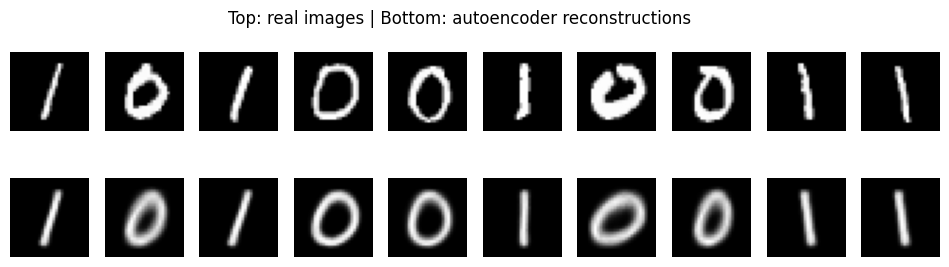

In [15]:
n = 10
reconstructed = autoencoder.predict(x_test[:n], verbose=0)

fig, axes = plt.subplots(2, n, figsize=(12, 3))
for i in range(n):
    axes[0, i].imshow(x_test[i], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructed[i], cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Real", fontsize=10)
axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
plt.suptitle("Top: real images | Bottom: autoencoder reconstructions")
plt.show()

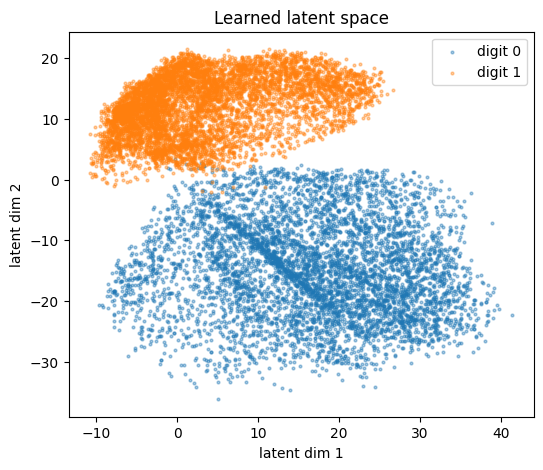

In [16]:
# Look at where real 0s and 1s land in latent space, to sample from a sensible region
z_train = encoder.predict(x_train, verbose=0)

plt.figure(figsize=(6, 5))
plt.scatter(z_train[y_train == 0, 0], z_train[y_train == 0, 1], s=4, alpha=0.4, label="digit 0")
plt.scatter(z_train[y_train == 1, 0], z_train[y_train == 1, 1], s=4, alpha=0.4, label="digit 1")
plt.xlabel("latent dim 1")
plt.ylabel("latent dim 2")
plt.title("Learned latent space")
plt.legend()
plt.show()

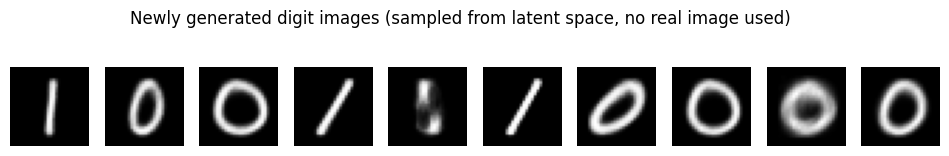

In [17]:
# Sample new random latent points within the observed range, and decode them into images
z_min, z_max = z_train.min(axis=0), z_train.max(axis=0)
n_generate = 10
random_latents = np.random.uniform(z_min, z_max, size=(n_generate, latent_dim))
generated_images = decoder.predict(random_latents, verbose=0)

fig, axes = plt.subplots(1, n_generate, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(generated_images[i], cmap="gray")
    ax.axis("off")
plt.suptitle("Newly generated digit images (sampled from latent space, no real image used)")
plt.show()

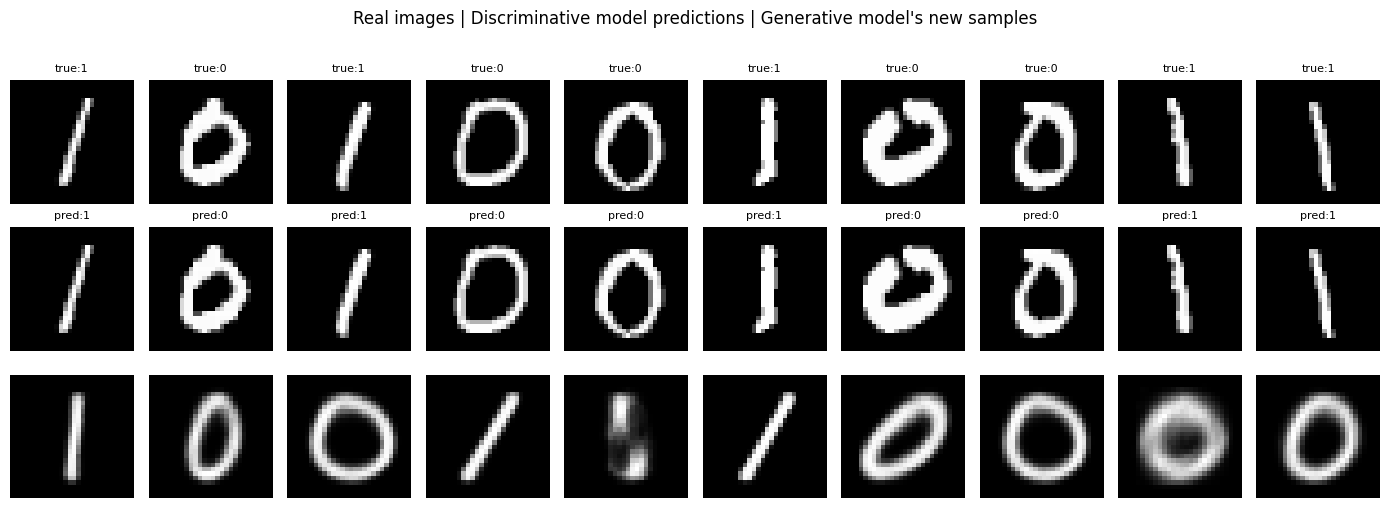

In [18]:
fig, axes = plt.subplots(3, 10, figsize=(14, 5))

for i in range(10):
    # Row 1: real test images with true label
    axes[0, i].imshow(x_test[i], cmap="gray")
    axes[0, i].set_title(f"true:{y_test[i]}", fontsize=8)
    axes[0, i].axis("off")

    # Row 2: same images with the discriminative model's prediction
    axes[1, i].imshow(x_test[i], cmap="gray")
    axes[1, i].set_title(f"pred:{y_pred[i]}", fontsize=8)
    axes[1, i].axis("off")

    # Row 3: brand-new images produced by the generative model
    axes[2, i].imshow(generated_images[i], cmap="gray")
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Real", fontsize=10)
axes[1, 0].set_ylabel("Discriminative\n(prediction)", fontsize=9)
axes[2, 0].set_ylabel("Generative\n(new sample)", fontsize=9)
plt.suptitle("Real images | Discriminative model predictions | Generative model's new samples", y=1.02)
plt.tight_layout()
plt.show()